## Week 1: Basic reinforcement learning concepts with applications

We're going to familiarize ourselves with basic concepts of reinforcement learning with code examples. 
Reinforcement learning is a framework for learning through interaction. An agent observes the current state of an environment, chooses an action, receives a reward or penalty, and uses this feedback to improve future decisions. This is useful in problems where we do not have a fixed dataset of correct answers, but where we can evaluate whether the outcome of a sequence of actions was good or bad.

RL is especially relevant for problems involving sequential decision-making:

- **Physics:** controlling quantum systems, finding low-energy configurations, improving sampling methods, or steering molecular dynamics simulations.
- **Robotics:** learning to walk, grasp objects, balance, navigate, or control motors.
- **Games:** learning strategies through repeated interaction and delayed rewards.
- **Optimization:** selecting effective sequences of decisions in large search spaces.
- **Agentic AI:** deciding when to use tools, ask questions, gather information, or take actions toward a goal.

## Repetition from the Lecture Notes

Reinforcement learning is a framework for studying how an **agent** can learn to make decisions by interacting with an **environment**. The key difference from a fixed-data learning problem is that the data are not given in advance. Instead, the data are generated through interaction: the agent chooses actions, and those actions influence what it observes next.

At each discrete time step $t = 0,1,2,\ldots$, the agent observes a **state** $S_t$, chooses an **action** $A_t$, receives a **reward** $R_{t+1}$, and the environment moves to a new state $S_{t+1}$. The basic interaction is

$S_t \rightarrow A_t \rightarrow (R_{t+1}, S_{t+1}).$

The notation emphasizes the causal order. The action $A_t$ is chosen at time $t$, while the reward $R_{t+1}$ and the next state $S_{t+1}$ are produced after the action has been applied. Repeating this interaction produces a sequence

$S_0, A_0, R_1, S_1, A_1, R_2, S_2, A_2, R_3, \ldots$

This sequence is called a **trajectory**. If the interaction stops after a finite number of steps, the trajectory is often called an **episode**.

To describe this interaction mathematically, we introduce a **state space** $S$, an **action space** $A$, and a **reward space** $R$. The random variables satisfy

$S_t \in S, \quad A_t \in A, \quad R_{t+1} \in R.$

The state $S_t$ is the information available to the agent when it must choose an action. The action $A_t$ is the decision made by the agent. The reward $R_{t+1}$ is the numerical feedback signal used to evaluate the consequence of that decision.

In some problems, not every action is available in every state. We therefore write $A(s)$ for the set of **available actions** in state $s$. A pair $(s,a)$ is called **admissible** if $a \in A(s)$. This matters because a policy should only assign probability to actions that the agent is actually allowed to take.

The rule used by the agent to choose actions is called a **policy**. A deterministic policy maps each state directly to an action,

$\pi : S \rightarrow A,$

so that

$A_t = \pi(S_t).$

More generally, a policy may be stochastic. In that case, the policy assigns probabilities to actions:

$\pi(a | s) = P(A_t = a | S_t = s).$

For each state $s$, these probabilities satisfy

$\sum_{a \in A(s)} \pi(a | s) = 1.$

Thus, the policy describes the agent's behavior. It tells us how likely the agent is to choose each action in each state.

The environment is described by how it responds to the agent's actions. Given a current state $s$ and an action $a$, the environment produces a next state $s'$ and a reward $r$. This is described by the **transition-reward probability**

$p(s', r | s,a) = P(S_{t+1}=s', R_{t+1}=r | S_t=s, A_t=a).$

In words, this is the probability that the next state is $s'$ and the reward is $r$, given that the agent took action $a$ in state $s$.

For each admissible state-action pair $(s,a)$, this is a probability distribution over possible next states and rewards:

$\sum_{s' \in S} \sum_{r \in R} p(s',r | s,a) = 1.$

The policy and the environment therefore play complementary roles. The policy describes how the agent chooses actions, while the transition-reward probability describes how the environment reacts to those actions:

$S_t \xrightarrow{\pi} A_t,$

$(S_t,A_t) \xrightarrow{p} (R_{t+1},S_{t+1}).$

Together, these two rules generate trajectories.

A standard assumption in reinforcement learning is the **Markov property**. This says that the distribution of the next state and reward depends only on the current state and action, not on the full previous history. If

$H_t = (S_0,A_0,R_1,\ldots,S_t,A_t)$

denotes the history up to time $t$, then the Markov property is

$P(S_{t+1}=s', R_{t+1}=r | H_t) = p(s',r | S_t,A_t).$

Intuitively, the current state should summarize everything from the past that is relevant for predicting what happens next. This is what makes it possible to model the environment using only the one-step transition rule $p(s',r | s,a)$.

To describe probabilities of full trajectories, we also need an **initial distribution** $\mu_0$, where

$\mu_0(s) = P(S_0=s).$

For a finite trajectory

$\tau = (s_0,a_0,r_1,s_1,a_1,r_2,\ldots,s_{T-1},a_{T-1},r_T,s_T),$

the probability of that trajectory under policy $\pi$ is

$P_\pi(\tau) = \mu_0(s_0) \prod_{t=0}^{T-1} \pi(a_t | s_t)p(s_{t+1}, r_{t+1} | s_t,a_t).$

This formula shows how the pieces fit together. The initial distribution chooses the starting state. The policy contributes the factors $\pi(a_t | s_t)$, which describe the agent's choices. The environment contributes the factors $p(s_{t+1},r_{t+1} | s_t,a_t)$, which describe the response to those choices. Changing the policy changes the distribution over trajectories, because the agent will choose different actions and therefore visit different future states.

The rewards along a trajectory are used to evaluate the policy. Since an action may have delayed consequences, the agent should not only care about the immediate reward. Instead, we define the **return** from time $t$ as the discounted sum of future rewards:

$G_t = \sum_{k=0}^{\infty} \gamma^k R_{t+k+1},$

where $\gamma \in [0,1]$ is the **discount factor**. If $\gamma=0$, only the next reward matters. If $\gamma$ is close to one, rewards far in the future still matter. For a finite episode ending at time $T$, the return is

$G_t = \sum_{k=0}^{T-t-1} \gamma^k R_{t+k+1}.$

The return satisfies the recursion

$G_t = R_{t+1} + \gamma G_{t+1}.$

This identity is important because it connects the return from the current time step to the return from the next time step. It is the basic recursive structure that later leads to Bellman equations.

The objective in reinforcement learning is to find a policy with large expected return. If the initial state is sampled from $\mu_0$, the **performance objective** of a policy is

$J_{\mu_0}(\pi) = E_\pi[G_0].$

Equivalently,

$J_{\mu_0}(\pi) = E_\pi[\sum_{t=0}^{\infty} \gamma^t R_{t+1}].$

The goal is therefore

$\pi^\star \in \operatorname*{arg,max}*{\pi} J*{\mu_0}(\pi).$

This is the main optimization problem in reinforcement learning. The policy is not trained to match fixed target labels. It is evaluated by the trajectories it generates and the rewards accumulated along those trajectories.

For learning and decision-making, it is often useful to assign values to states and actions. Fix a policy $\pi$. The **state-value function** is defined by

$v_\pi(s) = E_\pi[G_t | S_t=s].$

This is the expected return starting from state $s$, assuming the agent follows policy $\pi$ afterwards. It tells us how good it is to be in a state under the current policy.

The **action-value function** is defined by

$q_\pi(s,a) = E_\pi[G_t | S_t=s, A_t=a].$

This is the expected return obtained by first taking action $a$ in state $s$, and then following policy $\pi$ afterwards. Thus $v_\pi(s)$ evaluates states, while $q_\pi(s,a)$ evaluates actions in states.

The two are connected by

$v_\pi(s) = \sum_{a \in A(s)} \pi(a | s)q_\pi(s,a).$

This equation says that the value of a state is the average value of the available actions, weighted by the probabilities with which the policy chooses them. In other words, once a policy is fixed, the value of a state depends on which actions the policy tends to take from that state and how good those actions are in the long run.

The overall structure can be summarized as follows. The policy chooses actions. The environment responds with rewards and next states. This interaction creates trajectories. Trajectories define returns. Expected returns define the objective. Value functions then describe how much return we expect from particular states or state-action pairs.

In compact form:

$\text{policy} + \text{environment} \rightarrow \text{trajectories} \rightarrow \text{returns} \rightarrow \text{objective}.$

This is the basic reinforcement learning setup needed before building a simple agent. A simple agent only needs a way to choose actions, observe transitions of the form

$(S_t,A_t,R_{t+1},S_{t+1}),$

and update its behavior so that future actions lead to larger expected return.


In this course we will mostly use the *Gymnasium* library, but it is useful to first see the reinforcement learning loop without any external environment library. The goal is to understand what an environment does before we ask Gymnasium to provide one for us.


# A simple RL example

We start with a small grid-world. The agent begins in the upper-left corner and tries to reach the goal in the lower-right corner. Some cells are holes. If the agent reaches a hole, the episode ends with a negative reward. If the agent reaches the goal, the episode ends with a positive reward.

This example contains the same ingredients as a larger RL problem:

- The **state** is the agent's position on the grid.
- The **actions** are left, down, right, and up.
- The **reward** tells the agent whether the last move was useful.
- The **episode** ends when the agent reaches a hole, reaches the goal, or uses too many steps.
- The **policy** is the rule that chooses actions.

At first, the policy is not learned. We use a fixed sequence of actions so that the mechanics of `reset`, `step`, rewards, and episode traces are easy to see.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

class SimpleGridWorld:
    def __init__(self):
        self.grid = np.array([
            [0, 0, 0, 0],
            [0, -1, 0, -1],
            [0, 0, 0, -1],
            [-1, 0, 0, 1]
        ])
        self.start = (0, 0)
        self.goal = (3, 3)
        self.max_steps = 20
        self.actions = {
            0: (0, -1),
            1: (1, 0),
            2: (0, 1),
            3: (-1, 0)
        }
        self.action_names = {
            0: "left",
            1: "down",
            2: "right",
            3: "up"
        }
        self.reset()

    def reset(self):
        self.position = self.start
        self.steps = 0
        return self.position

    def step(self, action):
        row_change, col_change = self.actions[action]
        row, col = self.position
        next_row = np.clip(row + row_change, 0, self.grid.shape[0] - 1)
        next_col = np.clip(col + col_change, 0, self.grid.shape[1] - 1)
        self.position = (int(next_row), int(next_col))
        self.steps += 1

        cell_value = self.grid[self.position]
        terminated = cell_value != 0
        truncated = self.steps >= self.max_steps

        if cell_value == 1:
            reward = 1.0
        elif cell_value == -1:
            reward = -1.0
        else:
            reward = -0.02

        return self.position, reward, terminated, truncated


def draw_grid(env, path=None, title="Grid-world episode"):
    display_grid = env.grid.copy()
    display_grid[env.start] = 2
    display_grid[env.goal] = 3

    cmap = ListedColormap(["#d95f5f", "#f7f7f7", "#88c999", "#4c78a8"])
    shown = display_grid + 1

    fig, ax = plt.subplots(figsize=(5, 5))
    ax.imshow(shown, cmap=cmap, vmin=0, vmax=3)
    ax.set_xticks(np.arange(-0.5, env.grid.shape[1], 1), minor=True)
    ax.set_yticks(np.arange(-0.5, env.grid.shape[0], 1), minor=True)
    ax.grid(which="minor", color="black", linewidth=1)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(title)

    for row in range(env.grid.shape[0]):
        for col in range(env.grid.shape[1]):
            label = ""
            if (row, col) == env.start:
                label = "S"
            elif (row, col) == env.goal:
                label = "G"
            elif env.grid[row, col] == -1:
                label = "H"
            ax.text(col, row, label, ha="center", va="center", fontsize=14, weight="bold")

    if path is not None:
        rows = [p[0] for p in path]
        cols = [p[1] for p in path]
        ax.plot(cols, rows, color="black", linewidth=3, marker="o")

    plt.show()


The environment has two important methods. `reset()` starts a new episode and returns the initial state. `step(action)` applies one action and returns the next state, reward, and two flags telling us whether the episode has ended.

The code below follows a fixed path: right, right, down, down, down, right. This should reach the goal. Notice that the episode is bounded by `max_steps`, so it cannot run forever.


(0, 0) --right--> (0, 1), reward = -0.02
(0, 1) --right--> (0, 2), reward = -0.02
(0, 2) --down--> (1, 2), reward = -0.02
(1, 2) --down--> (2, 2), reward = -0.02
(2, 2) --down--> (3, 2), reward = -0.02
(3, 2) --right--> (3, 3), reward = 1.0
Total return: 0.9


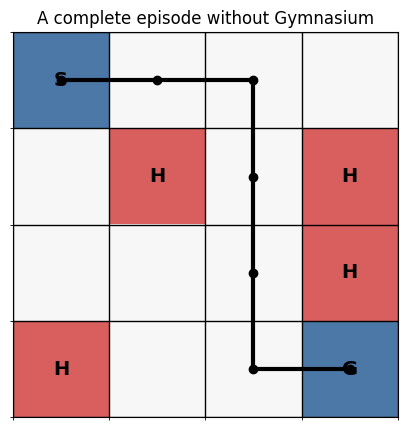

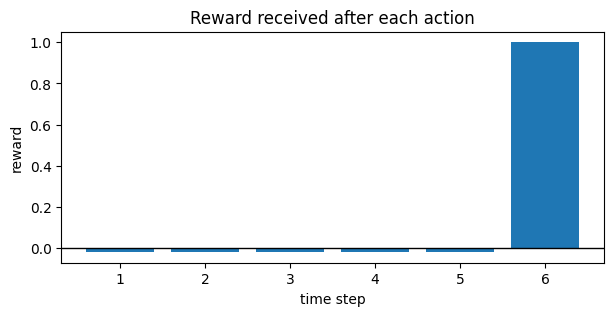

In [2]:
env = SimpleGridWorld()
state = env.reset()
planned_actions = [2, 2, 1, 1, 1, 2]
path = [state]
rewards = []
transitions = []

for action in planned_actions:
    next_state, reward, terminated, truncated = env.step(action)
    transitions.append((state, env.action_names[action], reward, next_state))
    rewards.append(reward)
    path.append(next_state)
    state = next_state
    if terminated or truncated:
        break

for old_state, action_name, reward, new_state in transitions:
    print(f"{old_state} --{action_name}--> {new_state}, reward = {reward}")

print("Total return:", sum(rewards))
draw_grid(env, path, "A complete episode without Gymnasium")

plt.figure(figsize=(7, 3))
plt.bar(np.arange(1, len(rewards) + 1), rewards)
plt.axhline(0, color="black", linewidth=1)
plt.xlabel("time step")
plt.ylabel("reward")
plt.title("Reward received after each action")
plt.show()


This small example shows what Gymnasium will later do for us. The environment stores the current state, updates it when an action is applied, computes the reward, and tells us when the episode is finished.

The agent could be a human, a fixed rule, a random policy, or a learning algorithm. The interface is the same: observe a state, choose an action, call `step`, and use the reward and next state.


# Gymnasium

**Gymnasium** is the maintained version of the old **OpenAI Gym** library. It provides ready-made reinforcement learning environments with a standard interface. This is useful because the same learning algorithm can often be tested on many different environments.

A Gymnasium environment follows the same loop as our small example:

$S_t \rightarrow A_t \rightarrow (R_{t+1}, S_{t+1}).$

The method `reset()` starts a new episode and returns the initial state. The method `step(action)` applies an action and returns

```python
next_state, reward, terminated, truncated, info
```

Here `terminated` means the task reached a terminal state, such as falling into a hole or reaching the goal. `truncated` means the episode stopped because of an external limit, such as a maximum number of steps.

We use `FrozenLake-v1`, which is also a grid-world. The agent starts on `S`, wants to reach `G`, and should avoid holes `H`.

You can find other examples in the Xiao ch. 1.6

In [3]:
import gymnasium as gym

frozen_env = gym.make("FrozenLake-v1", is_slippery=False, render_mode="ansi")
state, info = frozen_env.reset()

print("Initial state:", state)
print(frozen_env.render())


Initial state: 0

SFFF
FHFH
FFFH
HFFG



The action space is discrete. For `FrozenLake-v1`, the actions are encoded as integers:

- `0`: left
- `1`: down
- `2`: right
- `3`: up

A useful first experiment is to take one action and inspect all returned values. This makes the interface concrete before we run a full episode.


In [11]:
state, info = frozen_env.reset()
action = 2
next_state, reward, terminated, truncated, info = frozen_env.step(action)

print("State before action:", state)
print("Action:", action)
print("Next state:", next_state)
print("Reward:", reward)
print("Terminated:", terminated)
print("Truncated:", truncated)
print(frozen_env.render())


State before action: 0
Action: 2
Next state: 1
Reward: 0
Terminated: False
Truncated: False
  (Right)
SFFF
FHFH
FFFH
HFFG



Now we run a full episode using a fixed policy. Since `is_slippery=False`, the environment is deterministic. The action sequence below is chosen to reach the goal safely.

This replaces the interactive input loop with a bounded episode runner. That makes the notebook reproducible and prevents accidental infinite loops.


In [7]:
action_names = {
    0: "left",
    1: "down",
    2: "right",
    3: "up"
}

safe_policy_actions = [1, 1, 2, 1, 2, 2]
state, info = frozen_env.reset()
states = [state]
rewards = []
actions_taken = []
max_steps = 100

for step in range(max_steps):
    action = safe_policy_actions[step] if step < len(safe_policy_actions) else 0
    next_state, reward, terminated, truncated, info = frozen_env.step(action)
    actions_taken.append(action)
    rewards.append(reward)
    states.append(next_state)
    state = next_state
    if terminated or truncated:
        break

for index, action in enumerate(actions_taken):
    print(f"step {index + 1}: {action_names[action]}, state {states[index]} -> {states[index + 1]}, reward = {rewards[index]}")

print("Episode return:", sum(rewards))
print(frozen_env.render())


step 1: down, state 0 -> 4, reward = 0
step 2: down, state 4 -> 8, reward = 0
step 3: right, state 8 -> 9, reward = 0
step 4: down, state 9 -> 13, reward = 0
step 5: right, state 13 -> 14, reward = 0
step 6: right, state 14 -> 15, reward = 1
Episode return: 1
  (Right)
SFFF
FHFH
FFFH
HFFG



The state numbers in `FrozenLake-v1` correspond to grid positions. In the default `4 x 4` map, state `0` is the upper-left cell, state `1` is the next cell to the right, and so on. The figure below converts the recorded state sequence into a path through the grid.


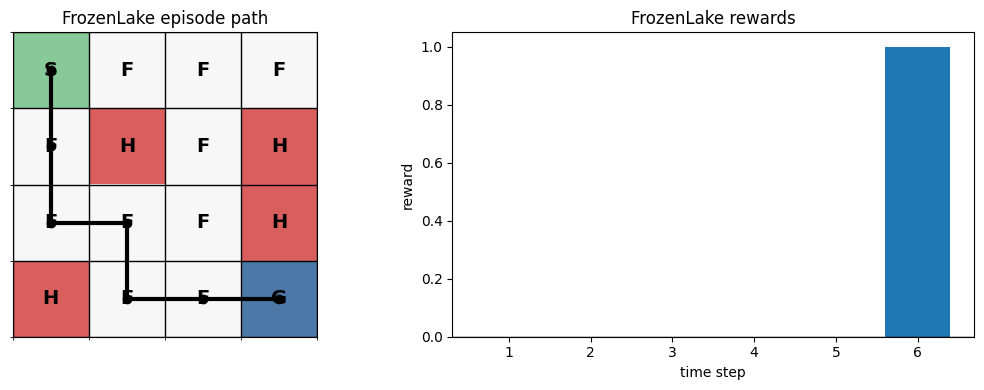

In [10]:
def state_to_row_col(state, n_cols=4):
    return divmod(state, n_cols)

frozen_map = np.array([
    list("SFFF"),
    list("FHFH"),
    list("FFFH"),
    list("HFFG")
])

colors = {
    "S": 0,
    "F": 1,
    "H": 2,
    "G": 3
}
color_grid = np.vectorize(colors.get)(frozen_map)
cmap = ListedColormap(["#88c999", "#f7f7f7", "#d95f5f", "#4c78a8"])

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].imshow(color_grid, cmap=cmap, vmin=0, vmax=3)
axes[0].set_xticks(np.arange(-0.5, 4, 1), minor=True)
axes[0].set_yticks(np.arange(-0.5, 4, 1), minor=True)
axes[0].grid(which="minor", color="black", linewidth=1)
axes[0].set_xticks([])
axes[0].set_yticks([])
axes[0].set_title("FrozenLake episode path")

for row in range(4):
    for col in range(4):
        axes[0].text(col, row, frozen_map[row, col], ha="center", va="center", fontsize=14, weight="bold")

path_positions = [state_to_row_col(s) for s in states]
rows = [p[0] for p in path_positions]
cols = [p[1] for p in path_positions]
axes[0].plot(cols, rows, color="black", linewidth=3, marker="o")

axes[1].bar(np.arange(1, len(rewards) + 1), rewards)
axes[1].axhline(0, color="black", linewidth=1)
axes[1].set_xlabel("time step")
axes[1].set_ylabel("reward")
axes[1].set_title("FrozenLake rewards")
plt.tight_layout()
plt.show()

frozen_env.close()


The important lesson is that our hand-written grid-world and Gymnasium's `FrozenLake-v1` have the same basic structure. Gymnasium saves us from writing the environment mechanics ourselves, but it does not change the reinforcement learning loop.

In later examples, we will replace the fixed action sequence with an agent that learns which actions to take from experience.


## Exercises

### Exercise 1: Why reinforcement learning?

Give a conceptual explanation of why reinforcement learning is different from supervised learning.

Your answer should discuss:

- Why the training data in supervised learning can be viewed as fixed, while the data in reinforcement learning are generated through interaction
- Why the output of a model in reinforcement learning should be interpreted as an action rather than only a prediction
- Why an action can influence the next state observed by the agent
- Why the reward from one step may not be enough to judge whether an action was good
- Why reinforcement learning uses accumulated reward, or return, as its objective

### Exercise 2: Recursive form of the return

The discounted return is defined as

$$
G_t = \sum_{k=0}^{\infty} \gamma^k R_{t+k+1},
\qquad 0 \leq \gamma < 1.
$$

Show that

$$
G_t = R_{t+1} + \gamma G_{t+1}.
$$

Then explain why this identity is important for temporal-difference learning.

### Exercise 3: Relation between state-value and action-value functions

For a fixed policy $\pi$, the state-value and action-value functions are defined by

$$
v_\pi(s) = \mathbb{E}_\pi[G_t \mid S_t=s],
$$

and

$$
q_\pi(s,a) = \mathbb{E}_\pi[G_t \mid S_t=s, A_t=a].
$$

Show that

$$
v_\pi(s)
=
\sum_{a \in A(s)}
\pi(a \mid s) q_\pi(s,a).
$$

Interpret this result in words. Why does this equation become especially simple for a deterministic policy?

### Exercise 4: Deriving the Bellman expectation equation

Starting from

$$
v_\pi(s) = \mathbb{E}_\pi[G_t \mid S_t=s],
$$

and using the recursion

$$
G_t = R_{t+1} + \gamma G_{t+1},
$$

show that

$$
v_\pi(s)
=
\sum_a \pi(a \mid s)
\sum_{s',r}
p(s',r \mid s,a)
\left[
r + \gamma v_\pi(s')
\right].
$$

Explain why this equation expresses a consistency condition for the value function of a fixed policy.

### Exercise 5: Greedy improvement from an action-value function

Assume that $q_\pi(s,a)$ is known for all states and actions under a policy $\pi$. Define a new deterministic policy $\pi'$ by

$$
\pi'(s) \in \arg\max_a q_\pi(s,a).
$$

Show that, for every state $s$,

$$
q_\pi(s,\pi'(s)) \geq v_\pi(s).
$$

Use this inequality to explain why choosing greedy actions with respect to $q_\pi$ is a natural policy improvement step. What additional argument would be needed to prove that $v_{\pi'}(s) \geq v_\pi(s)$ for all states?